In [1]:
import pandas as pd

# 데이터 로드
residual1 = pd.read_csv('data/z24_residual_features_frac_0.1.csv')
residual2 = pd.read_csv('data/z24_residual_features_frac_0.2.csv')
residual3 = pd.read_csv('data/z24_residual_features_frac_0.3.csv')

In [2]:
from pct import PCTChart

# --------------------------------------------------
# 1) Use preloaded dataframe: residual1
# --------------------------------------------------
df = residual1.copy()

# feature columns: exclude index/status columns
feature_cols = [c for c in df.columns if c not in ["sample_idx", "status"]]

X = df[feature_cols].copy()
y = df["status"].copy()

# numeric conversion
X = X.apply(pd.to_numeric, errors="coerce")

# --------------------------------------------------
# 2) Split
# --------------------------------------------------
train_mask = df["sample_idx"].between(0, 199)
normal_mask = df["sample_idx"].between(200, 319)
damaged_mask = df["sample_idx"].between(320, 399)

X_train = X.loc[train_mask].to_numpy(dtype=float)
X_normal = X.loc[normal_mask].to_numpy(dtype=float)
X_damaged = X.loc[damaged_mask].to_numpy(dtype=float)

y_normal = y.loc[normal_mask].to_numpy()
y_damaged = y.loc[damaged_mask].to_numpy()

# --------------------------------------------------
# 3) Fit PCT
# --------------------------------------------------
pct = PCTChart(alpha=0.05)
pct.fit(X_train)

# --------------------------------------------------
# 4) Score
# --------------------------------------------------
res_normal = pct.score_samples(X_normal)
res_damaged = pct.score_samples(X_damaged)

normal_alarm = res_normal.alarms
damaged_alarm = res_damaged.alarms

far = normal_alarm.mean()
detection_rate = damaged_alarm.mean()

# --------------------------------------------------
# 5) Summary
# --------------------------------------------------
print("=" * 70)
print("PCT Evaluation Summary")
print("=" * 70)
print(f"# train samples         : {len(X_train)}")
print(f"# unseen normal samples : {len(X_normal)}")
print(f"# damaged samples       : {len(X_damaged)}")
print("-" * 70)
print(f"False Alarm Rate (200~319) : {far:.4f} ({normal_alarm.sum()}/{len(normal_alarm)})")
print(f"Detection Rate  (320~399) : {detection_rate:.4f} ({damaged_alarm.sum()}/{len(damaged_alarm)})")
print("=" * 70)

# --------------------------------------------------
# 6) Detailed result table
# --------------------------------------------------
result_normal = pd.DataFrame({
    "sample_idx": df.loc[normal_mask, "sample_idx"].values,
    "status": y_normal,
    "Q_star": res_normal.q_values,
    "UCL": res_normal.ucls,
    "alarm": res_normal.alarms,
    "n_obs_vars": res_normal.n_obs_vars,
    "df": res_normal.dfs,
    "scale": res_normal.scales,
})

result_damaged = pd.DataFrame({
    "sample_idx": df.loc[damaged_mask, "sample_idx"].values,
    "status": y_damaged,
    "Q_star": res_damaged.q_values,
    "UCL": res_damaged.ucls,
    "alarm": res_damaged.alarms,
    "n_obs_vars": res_damaged.n_obs_vars,
    "df": res_damaged.dfs,
    "scale": res_damaged.scales,
})

result_all = pd.concat([result_normal, result_damaged], axis=0, ignore_index=True)

# --------------------------------------------------
# 7) Confusion summary
# --------------------------------------------------
tp = int(damaged_alarm.sum())
fn = int((~damaged_alarm).sum())
fp = int(normal_alarm.sum())
tn = int((~normal_alarm).sum())

print("\nConfusion-like summary")
print("-" * 70)
print(f"TN (normal -> normal) : {tn}")
print(f"FP (normal -> alarm)  : {fp}")
print(f"FN (damage -> normal) : {fn}")
print(f"TP (damage -> alarm)  : {tp}")

# 필요하면 저장
# result_all.to_csv("pct_results_frac_0.1.csv", index=False)


PCT Evaluation Summary
# train samples         : 200
# unseen normal samples : 120
# damaged samples       : 80
----------------------------------------------------------------------
False Alarm Rate (200~319) : 0.1917 (23/120)
Detection Rate  (320~399) : 0.8750 (70/80)

Confusion-like summary
----------------------------------------------------------------------
TN (normal -> normal) : 97
FP (normal -> alarm)  : 23
FN (damage -> normal) : 10
TP (damage -> alarm)  : 70


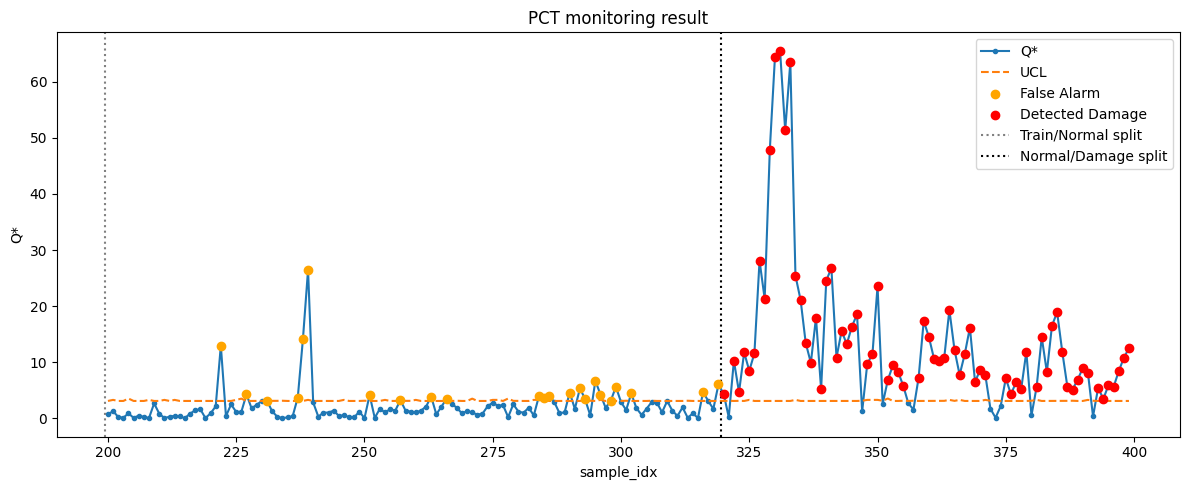

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(result_all["sample_idx"], result_all["Q_star"], label="Q*", marker="o", ms=3)
plt.plot(result_all["sample_idx"], result_all["UCL"], label="UCL", linestyle="--")

false_alarm_pts = result_all[(result_all["status"] == "Normal") & (result_all["alarm"] == True)]
detected_damage_pts = result_all[(result_all["status"] == "Damaged") & (result_all["alarm"] == True)]

plt.scatter(false_alarm_pts["sample_idx"], false_alarm_pts["Q_star"],
            color="orange", label="False Alarm", zorder=3)

plt.scatter(detected_damage_pts["sample_idx"], detected_damage_pts["Q_star"],
            color="red", label="Detected Damage", zorder=3)

plt.axvline(199.5, color="gray", linestyle=":", label="Train/Normal split")
plt.axvline(319.5, color="black", linestyle=":", label="Normal/Damage split")

plt.xlabel("sample_idx")
plt.ylabel("Q*")
plt.title("PCT monitoring result")
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
from pct import PCTChart

# --------------------------------------------------
# 1) Use preloaded dataframe: residual2
# --------------------------------------------------
df = residual2.copy()

# feature columns: exclude index/status columns
feature_cols = [c for c in df.columns if c not in ["sample_idx", "status"]]

X = df[feature_cols].copy()
y = df["status"].copy()

# numeric conversion
X = X.apply(pd.to_numeric, errors="coerce")

# --------------------------------------------------
# 2) Split
# --------------------------------------------------
train_mask = df["sample_idx"].between(0, 199)
normal_mask = df["sample_idx"].between(200, 319)
damaged_mask = df["sample_idx"].between(320, 399)

X_train = X.loc[train_mask].to_numpy(dtype=float)
X_normal = X.loc[normal_mask].to_numpy(dtype=float)
X_damaged = X.loc[damaged_mask].to_numpy(dtype=float)

y_normal = y.loc[normal_mask].to_numpy()
y_damaged = y.loc[damaged_mask].to_numpy()

# --------------------------------------------------
# 3) Fit PCT
# --------------------------------------------------
pct = PCTChart(alpha=0.05)
pct.fit(X_train)

# --------------------------------------------------
# 4) Score
# --------------------------------------------------
res_normal = pct.score_samples(X_normal)
res_damaged = pct.score_samples(X_damaged)

normal_alarm = res_normal.alarms
damaged_alarm = res_damaged.alarms

far = normal_alarm.mean()
detection_rate = damaged_alarm.mean()

# --------------------------------------------------
# 5) Summary
# --------------------------------------------------
print("=" * 70)
print("PCT Evaluation Summary")
print("=" * 70)
print(f"# train samples         : {len(X_train)}")
print(f"# unseen normal samples : {len(X_normal)}")
print(f"# damaged samples       : {len(X_damaged)}")
print("-" * 70)
print(f"False Alarm Rate (200~319) : {far:.4f} ({normal_alarm.sum()}/{len(normal_alarm)})")
print(f"Detection Rate  (320~399) : {detection_rate:.4f} ({damaged_alarm.sum()}/{len(damaged_alarm)})")
print("=" * 70)

# --------------------------------------------------
# 6) Detailed result table
# --------------------------------------------------
result_normal = pd.DataFrame({
    "sample_idx": df.loc[normal_mask, "sample_idx"].values,
    "status": y_normal,
    "Q_star": res_normal.q_values,
    "UCL": res_normal.ucls,
    "alarm": res_normal.alarms,
    "n_obs_vars": res_normal.n_obs_vars,
    "df": res_normal.dfs,
    "scale": res_normal.scales,
})

result_damaged = pd.DataFrame({
    "sample_idx": df.loc[damaged_mask, "sample_idx"].values,
    "status": y_damaged,
    "Q_star": res_damaged.q_values,
    "UCL": res_damaged.ucls,
    "alarm": res_damaged.alarms,
    "n_obs_vars": res_damaged.n_obs_vars,
    "df": res_damaged.dfs,
    "scale": res_damaged.scales,
})

result_all = pd.concat([result_normal, result_damaged], axis=0, ignore_index=True)

# --------------------------------------------------
# 7) Confusion summary
# --------------------------------------------------
tp = int(damaged_alarm.sum())
fn = int((~damaged_alarm).sum())
fp = int(normal_alarm.sum())
tn = int((~normal_alarm).sum())

print("\nConfusion-like summary")
print("-" * 70)
print(f"TN (normal -> normal) : {tn}")
print(f"FP (normal -> alarm)  : {fp}")
print(f"FN (damage -> normal) : {fn}")
print(f"TP (damage -> alarm)  : {tp}")

# 필요하면 저장
# result_all.to_csv("pct_results_frac_0.1.csv", index=False)


PCT Evaluation Summary
# train samples         : 200
# unseen normal samples : 120
# damaged samples       : 80
----------------------------------------------------------------------
False Alarm Rate (200~319) : 0.1500 (18/120)
Detection Rate  (320~399) : 0.8250 (66/80)

Confusion-like summary
----------------------------------------------------------------------
TN (normal -> normal) : 102
FP (normal -> alarm)  : 18
FN (damage -> normal) : 14
TP (damage -> alarm)  : 66


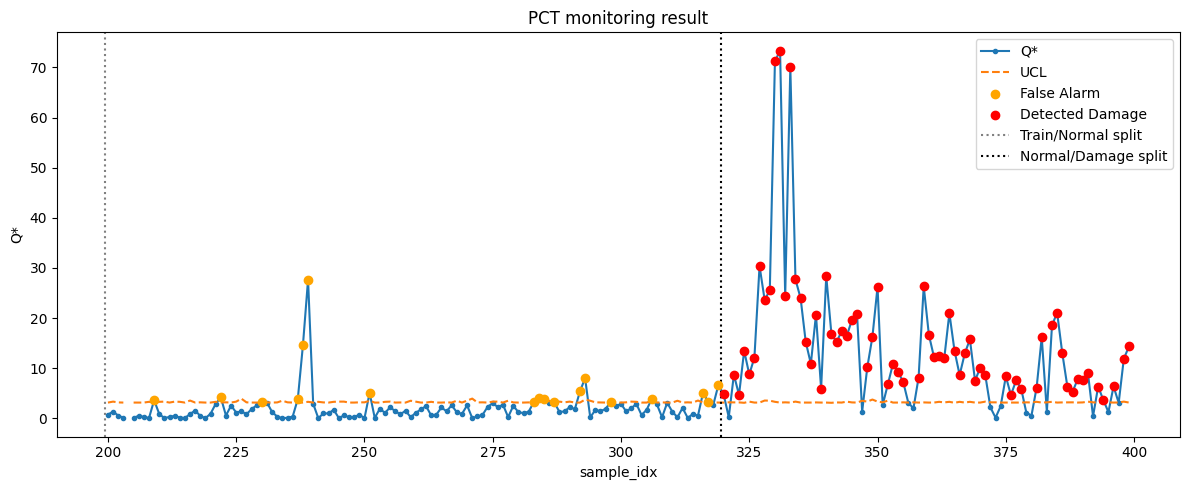

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(result_all["sample_idx"], result_all["Q_star"], label="Q*", marker="o", ms=3)
plt.plot(result_all["sample_idx"], result_all["UCL"], label="UCL", linestyle="--")

false_alarm_pts = result_all[(result_all["status"] == "Normal") & (result_all["alarm"] == True)]
detected_damage_pts = result_all[(result_all["status"] == "Damaged") & (result_all["alarm"] == True)]

plt.scatter(false_alarm_pts["sample_idx"], false_alarm_pts["Q_star"],
            color="orange", label="False Alarm", zorder=3)

plt.scatter(detected_damage_pts["sample_idx"], detected_damage_pts["Q_star"],
            color="red", label="Detected Damage", zorder=3)

plt.axvline(199.5, color="gray", linestyle=":", label="Train/Normal split")
plt.axvline(319.5, color="black", linestyle=":", label="Normal/Damage split")

plt.xlabel("sample_idx")
plt.ylabel("Q*")
plt.title("PCT monitoring result")
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
from pct import PCTChart

# --------------------------------------------------
# 1) Use preloaded dataframe: residual3
# --------------------------------------------------
df = residual3.copy()

# feature columns: exclude index/status columns
feature_cols = [c for c in df.columns if c not in ["sample_idx", "status"]]

X = df[feature_cols].copy()
y = df["status"].copy()

# numeric conversion
X = X.apply(pd.to_numeric, errors="coerce")

# --------------------------------------------------
# 2) Split
# --------------------------------------------------
train_mask = df["sample_idx"].between(0, 199)
normal_mask = df["sample_idx"].between(200, 319)
damaged_mask = df["sample_idx"].between(320, 399)

X_train = X.loc[train_mask].to_numpy(dtype=float)
X_normal = X.loc[normal_mask].to_numpy(dtype=float)
X_damaged = X.loc[damaged_mask].to_numpy(dtype=float)

y_normal = y.loc[normal_mask].to_numpy()
y_damaged = y.loc[damaged_mask].to_numpy()

# --------------------------------------------------
# 3) Fit PCT
# --------------------------------------------------
pct = PCTChart(alpha=0.05)
pct.fit(X_train)

# --------------------------------------------------
# 4) Score
# --------------------------------------------------
res_normal = pct.score_samples(X_normal)
res_damaged = pct.score_samples(X_damaged)

normal_alarm = res_normal.alarms
damaged_alarm = res_damaged.alarms

far = normal_alarm.mean()
detection_rate = damaged_alarm.mean()

# --------------------------------------------------
# 5) Summary
# --------------------------------------------------
print("=" * 70)
print("PCT Evaluation Summary")
print("=" * 70)
print(f"# train samples         : {len(X_train)}")
print(f"# unseen normal samples : {len(X_normal)}")
print(f"# damaged samples       : {len(X_damaged)}")
print("-" * 70)
print(f"False Alarm Rate (200~319) : {far:.4f} ({normal_alarm.sum()}/{len(normal_alarm)})")
print(f"Detection Rate  (320~399) : {detection_rate:.4f} ({damaged_alarm.sum()}/{len(damaged_alarm)})")
print("=" * 70)

# --------------------------------------------------
# 6) Detailed result table
# --------------------------------------------------
result_normal = pd.DataFrame({
    "sample_idx": df.loc[normal_mask, "sample_idx"].values,
    "status": y_normal,
    "Q_star": res_normal.q_values,
    "UCL": res_normal.ucls,
    "alarm": res_normal.alarms,
    "n_obs_vars": res_normal.n_obs_vars,
    "df": res_normal.dfs,
    "scale": res_normal.scales,
})

result_damaged = pd.DataFrame({
    "sample_idx": df.loc[damaged_mask, "sample_idx"].values,
    "status": y_damaged,
    "Q_star": res_damaged.q_values,
    "UCL": res_damaged.ucls,
    "alarm": res_damaged.alarms,
    "n_obs_vars": res_damaged.n_obs_vars,
    "df": res_damaged.dfs,
    "scale": res_damaged.scales,
})

result_all = pd.concat([result_normal, result_damaged], axis=0, ignore_index=True)

# --------------------------------------------------
# 7) Confusion summary
# --------------------------------------------------
tp = int(damaged_alarm.sum())
fn = int((~damaged_alarm).sum())
fp = int(normal_alarm.sum())
tn = int((~normal_alarm).sum())

print("\nConfusion-like summary")
print("-" * 70)
print(f"TN (normal -> normal) : {tn}")
print(f"FP (normal -> alarm)  : {fp}")
print(f"FN (damage -> normal) : {fn}")
print(f"TP (damage -> alarm)  : {tp}")

# 필요하면 저장
# result_all.to_csv("pct_results_frac_0.1.csv", index=False)


PCT Evaluation Summary
# train samples         : 200
# unseen normal samples : 120
# damaged samples       : 80
----------------------------------------------------------------------
False Alarm Rate (200~319) : 0.1333 (16/120)
Detection Rate  (320~399) : 0.8000 (64/80)

Confusion-like summary
----------------------------------------------------------------------
TN (normal -> normal) : 104
FP (normal -> alarm)  : 16
FN (damage -> normal) : 16
TP (damage -> alarm)  : 64


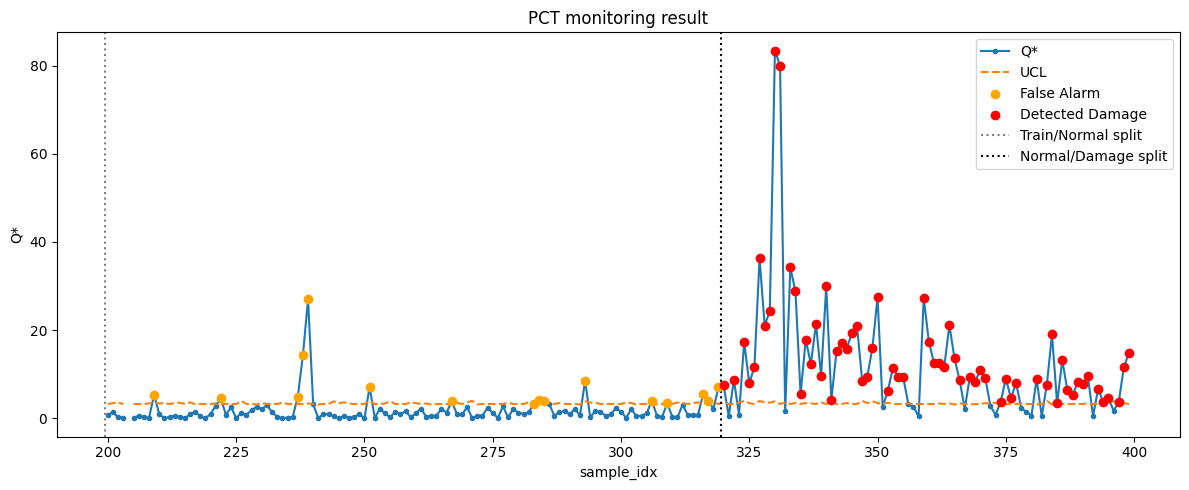

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(result_all["sample_idx"], result_all["Q_star"], label="Q*", marker="o", ms=3)
plt.plot(result_all["sample_idx"], result_all["UCL"], label="UCL", linestyle="--")

false_alarm_pts = result_all[(result_all["status"] == "Normal") & (result_all["alarm"] == True)]
detected_damage_pts = result_all[(result_all["status"] == "Damaged") & (result_all["alarm"] == True)]

plt.scatter(false_alarm_pts["sample_idx"], false_alarm_pts["Q_star"],
            color="orange", label="False Alarm", zorder=3)

plt.scatter(detected_damage_pts["sample_idx"], detected_damage_pts["Q_star"],
            color="red", label="Detected Damage", zorder=3)

plt.axvline(199.5, color="gray", linestyle=":", label="Train/Normal split")
plt.axvline(319.5, color="black", linestyle=":", label="Normal/Damage split")

plt.xlabel("sample_idx")
plt.ylabel("Q*")
plt.title("PCT monitoring result")
plt.legend()
plt.tight_layout()
plt.show()
